# Extensions of the project

In [1]:
import sys
import os
import subprocess

print("Initialisation de l'environnement...")

# --- 1. GESTION DES LIBRAIRIES EXTERNES (Téléchargement auto) ---
def install_package(package):
    print(f"Téléchargement de '{package}' en cours...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    # On essaie d'importer les librairies "publiques"
    import torchvision
    import torch
    import pandas as pd
    import time
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import seaborn as sns
    print("Toutes les librairies externes sont déjà présentes.")

except ImportError as e:
    # Si une librairie manque (ex: seaborn), on installe tout le paquet d'un coup
    print(f"Il manque des librairies (Erreur: {e}). Installation en cours...")
    
    # On installe les classiques qui manquent souvent sur SSP Cloud
    pkgs = ["pandas", "matplotlib", "seaborn", "tqdm", "torch", "torchvision"]
    for pkg in pkgs:
        try:
            __import__(pkg) # Tente un import basique
        except ImportError:
            install_package(pkg)
            
    # On refait les imports après installation
    import torchvision
    import torch
    import pandas as pd
    import time
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    import seaborn as sns
    print("Installation terminée et librairies chargées.")


# --- 2. GESTION DE TES FICHIERS LOCAUX (Neural_networks.py, etc) ---
try:
    # C'est ici qu'on charge ton code à toi
    from Neural_networks import *
    from Comparing_results import *
    from Extension_analysis_functions import *
    print("Tes fichiers locaux (Neural_networks, Comparing_results, Extension_analysis_functions) sont bien chargés.")

except ImportError as e:
    print("\n" + "_"*60)
    print(f"ERREUR : Impossible de trouver le fichier '{e.name}'.")
    print("SOLUTION : Tu dois 'Uploader' (Glisser-Déposer) tes fichiers .py")
    print("(Neural_networks.py, Comparing_results.py, Helper_functions.py)")
    print("dans la barre de gauche de VS Code ou Jupyter.")
    print("_"*60 + "\n")


# --- 3. VÉRIFICATION GPU (Pour être sûr que tu vas vite) ---
if torch.cuda.is_available():
    print(f"\nEXCELLENT : GPU détecté -> {torch.cuda.get_device_name(0)}")
else:
    print("\nATTENTION : Aucun GPU détecté. L'entraînement sera lent (CPU).")

Initialisation de l'environnement...
Il manque des librairies (Erreur: No module named 'torchvision'). Installation en cours...
Téléchargement de 'matplotlib' en cours...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Téléchargement de 'seaborn' en cours...
Téléchargement de 'tqdm' en cours...
Téléchargement de 'torch' en cours...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 60.5 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 73.1 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 92.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 83.3 MB/s  0:00:016m0:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 74.2 MB/s 

## Extension: "Late Rewinding" (Reset to Epoch k)

This extension is applied when standard Lottery Ticket Hypothesis experiments fail to identify winning tickets, typically on complex datasets like CIFAR-10 or with deeper network architectures. Resetting weights strictly to initialization (Epoch 0) can be unstable because the optimization trajectory is highly sensitive to stochastic noise during the very first iterations. Late Rewinding addresses this by resetting the pruned network's weights to their state after a small number of warmup epochs (e.g., Epoch 2) instead of the initial state. By this point, the network has entered a stable optimization basin, allowing the sparse subnetwork to train successfully without diverging. Consequently, this method maintains high accuracy at extreme sparsity levels where the standard initialization approach often collapses.

In [2]:
# --- PARAMÈTRES DE L'EXTENSION ---
# On pousse le pruning très loin (98%) pour voir la différence de stabilité
TOTAL_PRUNE_PERCENT = 90
ROUNDS = 5
EPOCHS = 5
REPEATS = 3
REWIND_EPOCH = 2 # On reset à l'époque 2 (Standard LTH = Reset à 0)
safe_lr=0.01

# --- DÉFINITION DES MÉTHODES ---

# Méthode 1 : Standard LTH (Reset à 0)
def method_standard_lth():
    return iterative_pruning_CIFAR(
        total_prune_percent=TOTAL_PRUNE_PERCENT,
        rounds=ROUNDS,
        epochs_per_round=EPOCHS,
        lr=0.01,
        LTH=True,
        optimizer_type="sgd"
    )

# Méthode 2 : Late Rewinding (Reset à l'époque 2)
def method_late_rewinding():
    return iterative_pruning_CIFAR_Rewinding(
        total_prune_percent=TOTAL_PRUNE_PERCENT,
        rounds=ROUNDS,
        epochs_per_round=EPOCHS,
        rewind_epoch=REWIND_EPOCH, # <-- Le changement clé
        lr=0.01,
        optimizer_type="sgd"
    )

print("🚀 Lancement de la comparaison : Standard vs Late Rewinding sur CIFAR-10...")

df_std, df_rewind = comparing_methods_initialization_after_pruning(
    amount_of_repeats=REPEATS,
    rounds=ROUNDS,
    method_1=method_standard_lth,
    method_2=method_late_rewinding
)


🚀 Lancement de la comparaison : Standard vs Late Rewinding sur CIFAR-10...


Repeats:   0%|          | 0/3 [00:00<?, ?it/s]


Step 1 and 2: training the randomly initialized neural network for CIFAR.
   -> Optimizer used: SGD (momentum=0.9)
Initial accuracy : 56.46%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 36.90% of the weights.

--- Round 1/5 ---
Current pruning percentage: 36.88%
Accuracy after retraining: 68.90%

--- Round 2/5 ---
Current pruning percentage: 60.15%
Accuracy after retraining: 72.15%

--- Round 3/5 ---
Current pruning percentage: 74.83%
Accuracy after retraining: 76.31%

--- Round 4/5 ---
Current pruning percentage: 84.09%
Accuracy after retraining: 77.42%

--- Round 5/5 ---
Current pruning percentage: 89.93%
Accuracy after retraining: 76.34%

Step 1: Training Dense Network with Rewinding capture at Epoch 2...
   -> Warming up for 2 epochs...
   -> Theta_2 saved! (Checkpoint created)
Initial dense accuracy : 70.24%. Loss: 0.8596

Step 4: Creating the Winning ticket (Reset to Epoch 2)

--- Round 1/5 ---
Accuracy: 79.17%. Loss: 0.5984

--- Round 2/5 ---
Accuracy: 

Repeats:  33%|███▎      | 1/3 [31:43<1:03:27, 1903.85s/it]

Accuracy: 82.60%. Loss: 0.4622

Step 1 and 2: training the randomly initialized neural network for CIFAR.
   -> Optimizer used: SGD (momentum=0.9)
Initial accuracy : 55.62%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 36.90% of the weights.

--- Round 1/5 ---
Current pruning percentage: 36.88%
Accuracy after retraining: 68.34%

--- Round 2/5 ---
Current pruning percentage: 60.15%
Accuracy after retraining: 75.46%

--- Round 3/5 ---
Current pruning percentage: 74.83%
Accuracy after retraining: 77.93%

--- Round 4/5 ---
Current pruning percentage: 84.09%
Accuracy after retraining: 78.04%

--- Round 5/5 ---
Current pruning percentage: 89.93%
Accuracy after retraining: 76.79%

Step 1: Training Dense Network with Rewinding capture at Epoch 2...
   -> Warming up for 2 epochs...
   -> Theta_2 saved! (Checkpoint created)
Initial dense accuracy : 71.68%. Loss: 0.8207

Step 4: Creating the Winning ticket (Reset to Epoch 2)

--- Round 1/5 ---
Accuracy: 78.54%. Loss: 0.627

Repeats:  67%|██████▋   | 2/3 [1:03:27<31:43, 1903.74s/it]

Accuracy: 84.01%. Loss: 0.4276

Step 1 and 2: training the randomly initialized neural network for CIFAR.
   -> Optimizer used: SGD (momentum=0.9)
Initial accuracy : 55.26%.

Step 4: Creating the Winning ticket
At each round, we are pruning : 36.90% of the weights.

--- Round 1/5 ---
Current pruning percentage: 36.88%
Accuracy after retraining: 66.06%

--- Round 2/5 ---
Current pruning percentage: 60.15%
Accuracy after retraining: 71.24%

--- Round 3/5 ---
Current pruning percentage: 74.83%
Accuracy after retraining: 77.30%

--- Round 4/5 ---
Current pruning percentage: 84.09%
Accuracy after retraining: 77.30%

--- Round 5/5 ---
Current pruning percentage: 89.93%
Accuracy after retraining: 74.61%

Step 1: Training Dense Network with Rewinding capture at Epoch 2...
   -> Warming up for 2 epochs...
   -> Theta_2 saved! (Checkpoint created)
Initial dense accuracy : 70.20%. Loss: 0.8744

Step 4: Creating the Winning ticket (Reset to Epoch 2)

--- Round 1/5 ---
Accuracy: 79.63%. Loss: 0.576

Repeats: 100%|██████████| 3/3 [1:35:21<00:00, 1907.11s/it]

Accuracy: 83.61%. Loss: 0.4314
Total time: 95.36 minutes


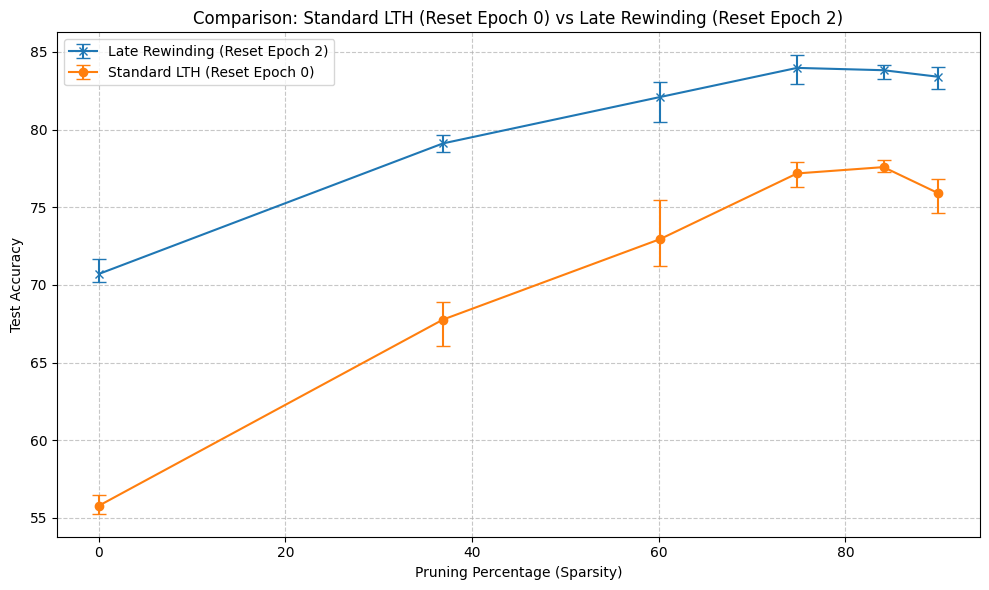

In [3]:
# --- AFFICHAGE ---
comparing_methods_plotting(
    df_std, 
    df_rewind, 
    "Standard LTH (Reset Epoch 0)", 
    f"Late Rewinding (Reset Epoch {REWIND_EPOCH})",dataset_name="CIFAR-10"
)

## Extension: "Strong Lottery Ticket Hypothesis" (Pruning without Training)

Based on the theoretical proofs by Da Cunha et al. (2022), the Strong Lottery Ticket Hypothesis asserts that sufficiently overparameterized networks contain subnetworks that perform well without any weight training. This extension applies when investigating the intrinsic representational power of random initializations, where the goal is to optimize only the connectivity (the binary mask) while keeping the random weights frozen. Unlike the standard LTH which requires expensive retraining steps, this method demonstrates that finding the correct topological structure within random noise is sufficient for high performance. This effectively shifts the focus from optimizing parameter values to optimizing network architecture (pruning) as the primary learning mechanism.

In [4]:
# Test rapide : Est-ce qu'on peut atteindre une bonne perf en supprimant 50% des poids
# sans JAMAIS entraîner les valeurs des poids ?
acc = run_strong_lth_experiment(target_prune_percent=50, epochs=10, lr=0.1)

# Pour ton rapport, tu peux faire une boucle :
# sparsities = [10, 30, 50, 70, 90, 95]
# accuracies = []
# for s in sparsities:
#     acc = run_strong_lth_experiment(target_prune_percent=s, epochs=20)
#     accuracies.append(acc)
# Puis tracer la courbe !


🚀 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 50%
   -> Training mask scores...
   ✅ Résultat Strong LTH : 52.84% d'accuracy avec 50% de poids supprimés (et poids figés!).


🚀 Lancement du 'Sweep' Strong LTH (Analyse de la sparsité)...


Testing Sparsities:   0%|          | 0/7 [00:00<?, ?it/s]


🚀 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 0%
   -> Training mask scores...


Testing Sparsities:  14%|█▍        | 1/7 [11:36<1:09:36, 696.08s/it]

   ✅ Résultat Strong LTH : 20.37% d'accuracy avec 0% de poids supprimés (et poids figés!).

🚀 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 20%
   -> Training mask scores...


...

   ✅ Résultat Strong LTH : 48.59% d'accuracy avec 80% de poids supprimés (et poids figés!).

🚀 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 85%
   -> Training mask scores...


Testing Sparsities:  86%|████████▌ | 6/7 [1:09:31<11:34, 695.00s/it]

   ✅ Résultat Strong LTH : 43.85% d'accuracy avec 85% de poids supprimés (et poids figés!).

🚀 Lancement Strong LTH (Edge-Popup) | Cible Sparsité: 90%
   -> Training mask scores...


Testing Sparsities: 100%|██████████| 7/7 [1:21:06<00:00, 695.23s/it]

   ✅ Résultat Strong LTH : 39.39% d'accuracy avec 90% de poids supprimés (et poids figés!).

📊 Résultats bruts :
   Sparsity (%)  Test Accuracy (%)
0             0              20.37
1            20              46.11
2            50              57.98
3            70              53.24
4            80              48.59
5            85              43.85
6            90              39.39


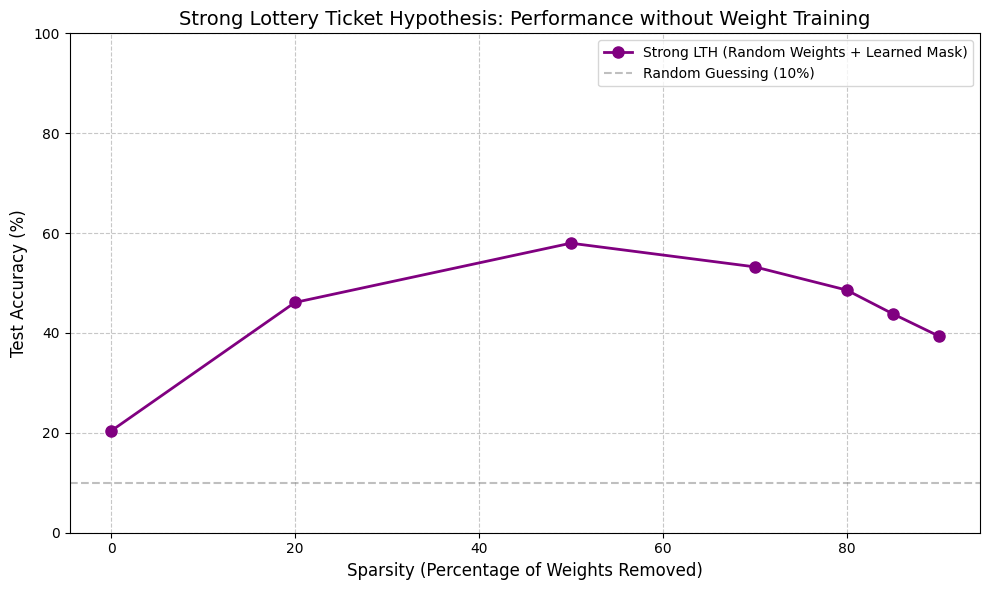

In [5]:
# --- 1. PARAMÈTRES DE L'EXPÉRIENCE ---
# Liste des sparsités à tester.
# On insiste sur la fin (90-99%) car c'est là que c'est impressionnant.
target_sparsities = [0, 20, 50, 70, 80, 85, 90] 
EPOCHS = 20  # Assez rapide, car on entraîne juste les scores (masques)
LR = 0.1     # Learning Rate pour les scores (Edge-Popup)

results = []

print("🚀 Lancement du 'Sweep' Strong LTH (Analyse de la sparsité)...")

# --- 2. BOUCLE D'EXPÉRIENCE ---
for sparsity in tqdm(target_sparsities, desc="Testing Sparsities"):
    # On lance l'expérience pour ce niveau de sparsité
    acc = run_strong_lth_experiment(
        target_prune_percent=sparsity, 
        epochs=EPOCHS, 
        lr=LR
    )
    
    results.append({
        "Sparsity (%)": sparsity,
        "Test Accuracy (%)": acc
    })

# Création d'un DataFrame pour voir les chiffres
df_results = pd.DataFrame(results)
print("\n📊 Résultats bruts :")
print(df_results)

# --- 3. PLOTTING (GRAPHIQUE RAPPORT) ---
plt.figure(figsize=(10, 6))

# Courbe Strong LTH
plt.plot(df_results["Sparsity (%)"], df_results["Test Accuracy (%)"], 
         marker='o', linestyle='-', linewidth=2, markersize=8, color='purple', label="Strong LTH (Random Weights + Learned Mask)")

# Ligne de base : Performance aléatoire (10% sur CIFAR-10)
plt.axhline(y=10, color='gray', linestyle='--', alpha=0.5, label="Random Guessing (10%)")

# (Optionnel) Ligne de référence : Performance d'un réseau entraîné normalement (~60-65% pour Conv2)
# Vous pouvez décommenter cette ligne pour montrer la différence avec un entraînement classique
# plt.axhline(y=65, color='green', linestyle='--', alpha=0.5, label="Standard Training Baseline")

# Esthétique
plt.title("Strong Lottery Ticket Hypothesis: Performance without Weight Training", fontsize=14)
plt.xlabel("Sparsity (Percentage of Weights Removed)", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(0, 100) # Pour bien voir l'échelle globale

# Sauvegarde pour le rapport
plt.tight_layout()
plt.savefig("Strong_LTH_Results.png", dpi=300)
plt.show()

In [8]:
df_rewind.columns

Index(['Round', 'Pruning Percentage', 'Avg Test Accuracy (with training)',
       'Min Test Accuracy (with training)',
       'Max Test Accuracy (with training)', 'Avg Time (min)', 'Min Time (min)',
       'Max Time (min)', 'Avg Final Training Loss', 'Min Final Training Loss',
       'Max Final Training Loss'],
      dtype='object')